# Building the final article-level market dataset

This notebook turns the raw article corpus, price data, earnings calendar, and market schedule into a single dataset for sequence / event-study modeling. The workflow is deliberately documented in the same style as the earlier notebooks in this repo: load the raw parquet files, inspect the data, compute the market features, then save the final row-per-article table.

The target table is designed to be merged with the article corpus on `article_id` and to add the event-study and pre-publication features needed for classification. We keep the article identifier fixed so the model can still access headline, summary, and any text features produced by the Person A side of the project.

The notebook covers the following output columns:

- `article_id`
- `abnormal_return_1d`
- `abnormal_return_3d`
- `label_direction`
- `momentum_1d`, `momentum_5d`, `momentum_20d`
- `volatility_20d`
- `days_to_earnings`
- `days_since_last_earnings`
- `session`
- `news_volume`
- `prior_return_1d`
- `beta_20d`
- `relative_volume_20d`
- `daily_range_ratio_1d`

The final parquet output is written to the project’s processed data folder, which keeps the modeling stage decoupled from the raw source data.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from stock_predictor.config import (
    NEWS_END_DATE,
    NEWS_START_DATE,
    PROCESSED_DATA_DIR,
    RAW_DATA_DIR,
    REPORTS_DIR,
)

print("Imports ready.")

2026-08-24 19:30:49.630 | INFO     | stock_predictor.config:<module>:12 - PROJ_ROOT path is: C:\Users\kacpe\OneDrive - University of Warwick\PROJECTS\Stock Predictor\stock-predictor


Imports ready.


## 1) Load the processed article inputs

The project already contains the processed article corpus in `data/processed/` and the remaining market inputs in `data/raw/`:

- `processed_articles.parquet` holds the standardized article metadata and publication times used for modeling.
- `raw_ohlcv.parquet` holds daily OHLCV for the company and benchmark index.
- `raw_earnings.parquet` holds the earnings calendar.
- `raw_schedule.parquet` holds market open and close times used to align publication times.

We are focusing on the `TSLA` corpus because the earlier notebooks and config are built around Tesla as the primary ticker. We then compute market features for each article using the first valid market day after publication, while removing broad index moves by subtracting `SPY` returns.

In [2]:
# Load processed article data and market inputs
articles = pd.read_parquet(PROCESSED_DATA_DIR / "processed_articles.parquet")
articles["timestamp_utc"] = pd.to_datetime(articles["timestamp_utc"], utc=True)

ohlcv = pd.read_parquet(RAW_DATA_DIR / "raw_ohlcv.parquet")

close = ohlcv.xs("Close", level="Price", axis=1).sort_index()
high = ohlcv.xs("High", level="Price", axis=1).sort_index()
low = ohlcv.xs("Low", level="Price", axis=1).sort_index()
volume = ohlcv.xs("Volume", level="Price", axis=1).sort_index()

for df in (close, high, low, volume):
    df.columns = [str(c).strip() for c in df.columns]
    df.index = pd.to_datetime(df.index).tz_localize("UTC")

close = close[["SPY", "TSLA"]].copy()
high = high[["SPY", "TSLA"]].copy()
low = low[["SPY", "TSLA"]].copy()
volume = volume[["SPY", "TSLA"]].copy()

schedule = pd.read_parquet(RAW_DATA_DIR / "raw_schedule.parquet")
schedule["market_open"] = pd.to_datetime(schedule["market_open"], utc=True)
schedule["market_close"] = pd.to_datetime(schedule["market_close"], utc=True)

earnings = pd.read_parquet(RAW_DATA_DIR / "raw_earnings.parquet")
earnings.index = pd.to_datetime(earnings.index)
if earnings.index.tz is None:
    earnings.index = earnings.index.tz_localize("UTC")
else:
    earnings.index = earnings.index.tz_convert("UTC")
# raw_earnings.parquet comes sorted newest-first; days_to_next_earnings() relies on
# earnings.index being ascending so `future[0]` is the *nearest* upcoming date, not the
# furthest one.
earnings = earnings.sort_index()

# Restrict to the project publication window defined in config.
start_ts = pd.Timestamp(NEWS_START_DATE, tz="UTC")
end_ts = pd.Timestamp(NEWS_END_DATE, tz="UTC")

print(f"Articles kept: {len(articles)}")
print(f"Price rows: {len(close)}")
print(f"Earnings dates: {len(earnings)}")
print(f"Schedule rows: {len(schedule)}")
print(articles[["article_id", "timestamp_utc"]].head())
print(close.head())
print(earnings.head())

Articles kept: 1975
Price rows: 284
Earnings dates: 5
Schedule rows: 259
   article_id             timestamp_utc
0   138802119 2025-08-31 17:00:00+00:00
1   139021751 2025-08-31 14:30:59+00:00
2   138690782 2025-08-31 11:31:32+00:00
3   136581238 2025-08-30 14:13:30+00:00
4   136581240 2025-08-30 10:45:00+00:00
                                  SPY        TSLA
Date                                             
2025-06-23 00:00:00+00:00  593.573059  348.679993
2025-06-24 00:00:00+00:00  600.130371  340.470001
2025-06-25 00:00:00+00:00  600.466614  327.549988
2025-06-26 00:00:00+00:00  605.164612  325.779999
2025-06-27 00:00:00+00:00  608.171204  323.630005
                           EPS Estimate  Reported EPS  Surprise(%)
Earnings Date                                                     
2025-10-22 20:00:00+00:00          0.56          0.50       -10.53
2026-01-28 21:00:00+00:00          0.45          0.50        10.96
2026-04-22 20:00:00+00:00          0.35          0.41        17.15
20

## 2) Market-alignment logic and feature definitions

The target is defined as an event-study move around the publication timestamp. Each article is mapped to the next market opening after publication, and the abnormal return is computed as:

$$
AR_{t,h} = R_{ticker, t+h} - R_{SPY, t+h}
$$

where $h$ is 1 or 3 trading days. The subtraction of the `SPY` return removes broad index movement and leaves the company-specific component.

We also create the pre-publication signals:

- `momentum_1d`, `momentum_5d`, `momentum_20d`: cumulative close-to-close percentage change over prior windows, measuring recent price continuation before publication.
- `volatility_20d`: rolling standard deviation of daily returns over the prior 20 trading days, capturing short-term stock instability.
- `prior_return_1d`: the 1-day lagged return from the previous trading session, giving a direct look at the most recent price move.
- `beta_20d`: a 20-day rolling beta versus `SPY`, measuring how strongly TSLA moves with the wider market.
- `relative_volume_20d`: current TSLA volume relative to its recent 20-day median, indicating whether trading activity is unusually elevated.
- `daily_range_ratio_1d`: the previous day’s intraday high-low range divided by the prior close, capturing short-term volatility relative to price level.
- `days_to_earnings`: calendar distance to the next earnings date, a key event-driven market timing feature.
- `session`: pre-market, market-hours, or after-hours based on publication timestamp.
- `news_volume`: count of TSLA articles in the prior 3-day window, a proxy for article intensity and information flow.

The code below keeps the calculations explicit and easy to audit.

In [3]:
from stock_predictor.market.timestamp_alignment import align_timestamp


def session_for(ts: pd.Timestamp) -> str:
    """Assign a market session based on the publication timestamp."""
    same_day = schedule[schedule["market_open"].dt.date == ts.date()]
    if same_day.empty:
        return "after-hours"

    row = same_day.iloc[0]
    if ts < row["market_open"]:
        return "pre-market"
    if ts <= row["market_close"]:
        return "market-hours"
    return "after-hours"

def cumulative_return(series: pd.Series, ref_date: pd.Timestamp, lookback_days: int):
    """Return the cumulative return over the prior lookback window."""
    ref_date = pd.Timestamp(ref_date)
    if ref_date.tzinfo is None:
        ref_date = ref_date.tz_localize("UTC")
    hist = series[series.index < ref_date].sort_index()
    if len(hist) <= lookback_days:
        return np.nan
    start = hist.iloc[-(lookback_days + 1)]
    end = hist.iloc[-1]
    return end / start - 1

def rolling_volatility(series: pd.Series, ref_date: pd.Timestamp, window: int = 20):
    """Rolling std dev of daily returns over the prior trading window."""
    ref_date = pd.Timestamp(ref_date)
    if ref_date.tzinfo is None:
        ref_date = ref_date.tz_localize("UTC")
    hist = series[series.index < ref_date].sort_index().tail(window)
    if len(hist) < 2:
        return np.nan
    return hist.pct_change().dropna().std(ddof=1)


def days_to_next_earnings(article_date: pd.Timestamp):
    """Compute calendar distance to the next earnings date."""
    future = earnings.index[earnings.index >= article_date]
    if future.empty:
        return np.nan
    next_earn = future[0]
    return (next_earn.normalize() - article_date.normalize()).days

def prior_return(series: pd.Series, ref_date: pd.Timestamp, lookback_days: int = 1):
    """Daily or multi-day prior return computed from earlier price observations."""
    ref_date = pd.Timestamp(ref_date)
    if ref_date.tzinfo is None:
        ref_date = ref_date.tz_localize("UTC")
    hist = series[series.index < ref_date].sort_index()
    if len(hist) <= lookback_days:
        return np.nan
    start = hist.iloc[-(lookback_days + 1)]
    end = hist.iloc[-1]
    return end / start - 1


def beta_vs_market(ref_date: pd.Timestamp, window: int = 20):
    """Estimate the 20-day market beta using TSLA vs SPY daily returns."""
    ref_date = pd.Timestamp(ref_date)
    if ref_date.tzinfo is None:
        ref_date = ref_date.tz_localize("UTC")

    hist = pd.concat(
        [
            close["TSLA"].rename("asset"),
            close["SPY"].rename("market"),
        ],
        axis=1,
    )
    hist = hist[hist.index < ref_date].sort_index().tail(window)
    if len(hist) < 3:
        return np.nan

    ret = hist.pct_change().dropna()
    if ret.empty:
        return np.nan

    x = ret["market"]
    y = ret["asset"]
    if x.nunique() < 2 or y.nunique() < 2:
        return np.nan

    slope = np.polyfit(x.to_numpy(), y.to_numpy(), 1)[0]
    return float(slope)


def relative_volume(ref_date: pd.Timestamp, window: int = 20):
    """Compare current TSLA volume against the recent rolling median."""
    ref_date = pd.Timestamp(ref_date)
    if ref_date.tzinfo is None:
        ref_date = ref_date.tz_localize("UTC")

    hist = volume["TSLA"][volume["TSLA"].index < ref_date].sort_index().tail(window)
    if hist.empty:
        return np.nan
    current = hist.iloc[-1]
    median = hist.median()
    if pd.isna(median) or median == 0:
        return np.nan
    return current / median


def daily_range_ratio(ref_date: pd.Timestamp):
    """Previous-day intraday range scaled by prior close."""
    ref_date = pd.Timestamp(ref_date)
    if ref_date.tzinfo is None:
        ref_date = ref_date.tz_localize("UTC")

    hist = pd.concat(
        [
            high["TSLA"].rename("high"),
            low["TSLA"].rename("low"),
            close["TSLA"].rename("close"),
        ],
        axis=1,
    )
    hist = hist[hist.index < ref_date].sort_index()
    if hist.empty:
        return np.nan

    prev = hist.iloc[-1]
    if prev["close"] == 0:
        return np.nan
    return (prev["high"] - prev["low"]) / prev["close"]


def abnormal_return_for(ts: pd.Timestamp, horizon_days: int):
    """Ticker return minus SPY return over the specified trading-day horizon."""
    event_open = align_timestamp(ts, schedule)
    event_date = event_open.normalize()
    if event_date not in close.index:
        return np.nan

    event_pos = close.index.get_loc(event_date)
    prev_pos = event_pos - 1
    if prev_pos < 0:
        return np.nan

    end_pos = min(event_pos + max(horizon_days - 1, 0), len(close) - 1)
    end_date = close.index[end_pos]
    prev_date = close.index[prev_pos]

    ticker_ret = close.loc[end_date, "TSLA"] / close.loc[prev_date, "TSLA"] - 1
    spy_ret = close.loc[end_date, "SPY"] / close.loc[prev_date, "SPY"] - 1
    return ticker_ret - spy_ret

# Example diagnostics for one row.
example_ts = articles["timestamp_utc"].iloc[0]
print(f"Example publication timestamp: {example_ts}")
print(f"Next market open: {align_timestamp(example_ts, schedule)}")
print(f"Session: {session_for(example_ts)}")
print(f"1-day abnormal return: {abnormal_return_for(example_ts, 1):.4f}")
print(f"3-day abnormal return: {abnormal_return_for(example_ts, 3):.4f}")

Example publication timestamp: 2025-08-31 17:00:00+00:00
Next market open: 2025-09-02 13:30:00+00:00
Session: after-hours
1-day abnormal return: -0.0061
3-day abnormal return: 0.0076


In [4]:
# Build the feature table with one row per article.
features = articles[["article_id", "timestamp_utc"]].copy()
features["article_date"] = features["timestamp_utc"].dt.normalize()
features["session"] = features["timestamp_utc"].apply(session_for)
features["days_to_earnings"] = features["article_date"].apply(days_to_next_earnings)

# Pre-publication momentum and volatility: keep all comparisons timezone-aware.
for lookback in [1, 5, 20]:
    features[f"momentum_{lookback}d"] = features.apply(
        lambda r: cumulative_return(close["TSLA"], r["timestamp_utc"], lookback), axis=1
    )

features["volatility_20d"] = features.apply(
    lambda r: rolling_volatility(close["TSLA"], r["timestamp_utc"], window=20), axis=1
)
features["prior_return_1d"] = features["timestamp_utc"].apply(
    lambda ts: prior_return(close["TSLA"], ts, lookback_days=1)
)
features["beta_20d"] = features["timestamp_utc"].apply(beta_vs_market)
features["relative_volume_20d"] = features["timestamp_utc"].apply(relative_volume)
features["daily_range_ratio_1d"] = features["timestamp_utc"].apply(daily_range_ratio)

# Event-study abnormal returns and label target.
features["abnormal_return_1d"] = features["timestamp_utc"].apply(lambda ts: abnormal_return_for(ts, 1))
features["abnormal_return_3d"] = features["timestamp_utc"].apply(lambda ts: abnormal_return_for(ts, 3))
features["label_direction"] = np.sign(features["abnormal_return_1d"]).fillna(0).astype(int)

# Count prior TSLA articles in the last 3 days.
features["news_volume"] = features["timestamp_utc"].apply(
    lambda ts: int(
        ((articles["timestamp_utc"] >= ts - pd.Timedelta(days=3))
         & (articles["timestamp_utc"] < ts)).sum()
    )
)

# Keep final output column order.
final = features[
    [
        "article_id",
        "abnormal_return_1d",
        "abnormal_return_3d",
        "label_direction",
        "momentum_1d",
        "momentum_5d",
        "momentum_20d",
        "prior_return_1d",
        "volatility_20d",
        "beta_20d",
        "relative_volume_20d",
        "daily_range_ratio_1d",
        "days_to_earnings",
        "session",
        "news_volume",
    ]
].copy()

final = final.sort_values("article_id").reset_index(drop=True)
final = final.dropna(subset=["abnormal_return_1d", "abnormal_return_3d"], how="all").copy()
print(final.head().to_string(index=False))
print(f"\nFinal feature rows: {len(final)}")
print(final.isna().sum())

 article_id  abnormal_return_1d  abnormal_return_3d  label_direction  momentum_1d  momentum_5d  momentum_20d  prior_return_1d  volatility_20d  beta_20d  relative_volume_20d  daily_range_ratio_1d  days_to_earnings      session  news_volume
  136476320            0.046809             0.08347                1     0.062166     0.028588      0.075777         0.062166        0.023487  2.205246             1.196079              0.060469                61   pre-market            0
  136476419            0.023783             0.02616                1     0.062166     0.028588      0.075777         0.062166        0.023487  2.205246             1.196079              0.060469                61 market-hours            8
  136476535            0.046809             0.08347                1     0.062166     0.028588      0.075777         0.062166        0.023487  2.205246             1.196079              0.060469                61   pre-market            5
  136476569            0.023783             

## 3) EDA and sanity checks

It is worth checking the feature distributions before modeling. The main questions are:

- Are the abnormal returns roughly centred around zero, or do large company-specific moves dominate?
- Are there enough observations in each market session?
- Are there any missing or degenerate values in momentum/volatility?
- Does the label distribution look balanced enough for a binary classification model?

If the distribution is very skewed or the dataset is sparse in a key session, that information should inform the modeling choices downstream.

       abnormal_return_1d  abnormal_return_3d  momentum_1d  momentum_5d  \
count           1973.0000           1973.0000    1973.0000    1973.0000   
mean               0.0034              0.0029       0.0050      -0.0003   
std                0.0235              0.0374       0.0287       0.0607   
min               -0.0484             -0.0664      -0.0464      -0.2024   
25%               -0.0143             -0.0228      -0.0149      -0.0339   
50%                0.0004              0.0035       0.0039       0.0000   
75%                0.0180              0.0208       0.0213       0.0429   
max                0.0681              0.1043       0.0846       0.1325   

       momentum_20d  volatility_20d  days_to_earnings  news_volume  
count     1973.0000       1973.0000         1973.0000    1973.0000  
mean        -0.0204          0.0295           58.4222      57.4709  
std          0.1428          0.0066           24.4810      32.5370  
min         -0.2907          0.0202            0

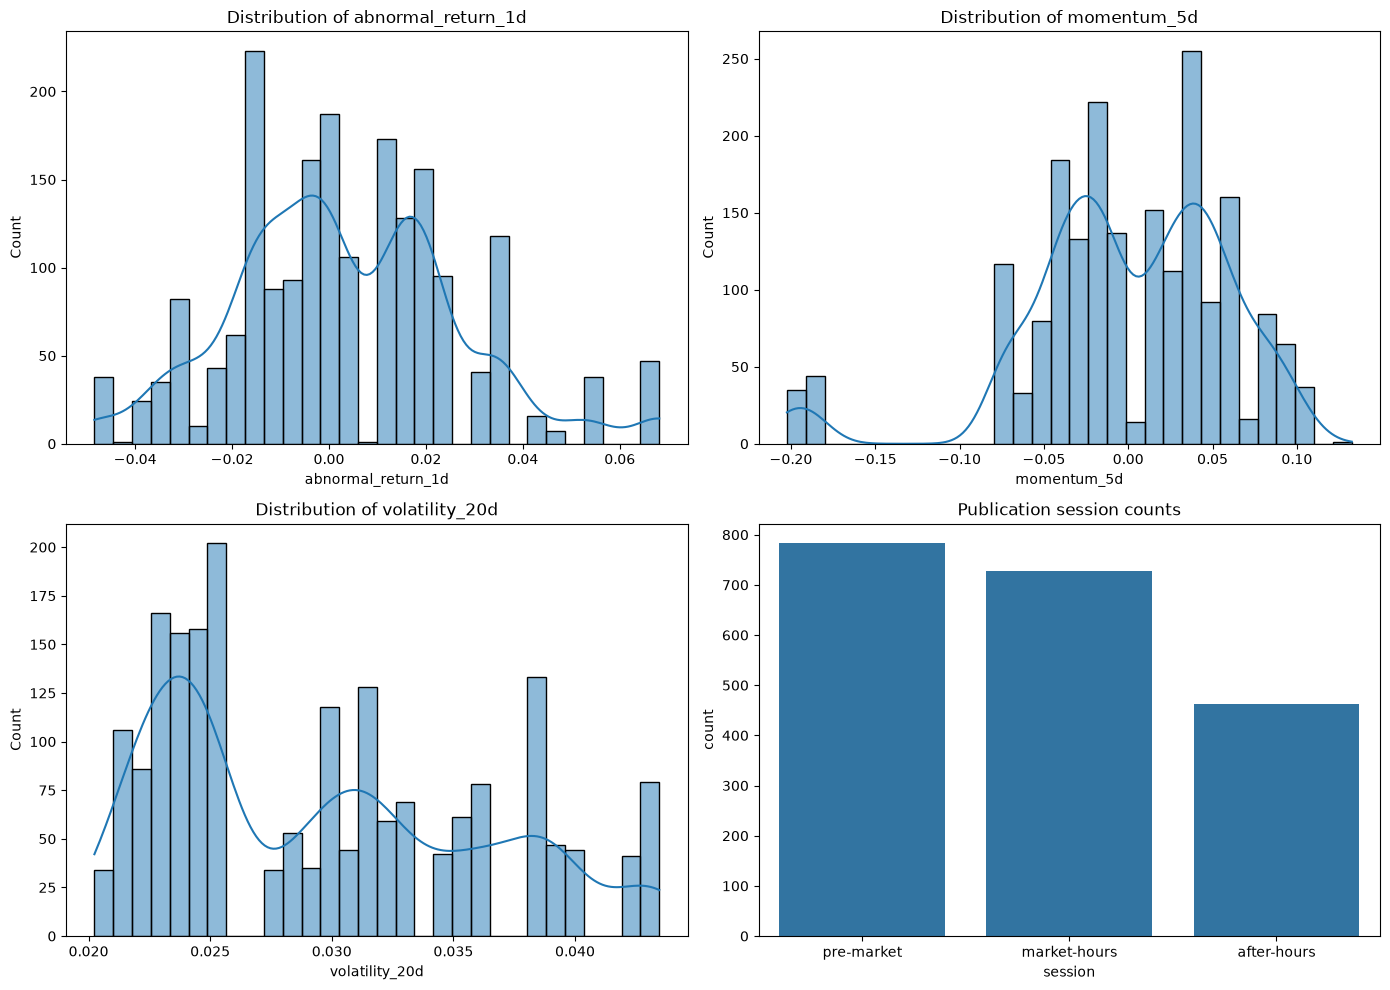

In [5]:
# Summary statistics for the final feature table.
summary = final[[
    "abnormal_return_1d",
    "abnormal_return_3d",
    "momentum_1d",
    "momentum_5d",
    "momentum_20d",
    "volatility_20d",
    "days_to_earnings",
    "news_volume",
]].describe().round(4)
print(summary)

print("\nSession counts:")
print(final["session"].value_counts().sort_index())

print("\nLabel counts:")
print(final["label_direction"].value_counts().sort_index())

# Visualize the distributions that matter for modeling.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(final["abnormal_return_1d"].dropna(), bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of abnormal_return_1d")

sns.histplot(final["momentum_5d"].dropna(), bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of momentum_5d")

sns.histplot(final["volatility_20d"].dropna(), bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of volatility_20d")

sns.countplot(data=final, x="session", ax=axes[1, 1])
axes[1, 1].set_title("Publication session counts")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "1.4-market_feature_eda.png", dpi=200)
plt.show()

From the plots, we see that abnormal return is roughly centered around 0, which is good. Also, the label count and the market hours count are both evenly spread.

## 4) Save the final parquet dataset

The final output is a single parquet file with one row per article and the exact columns the downstream model expects. This keeps the feature generation step separate from the text modeling work and makes it easy to reproduce the full pipeline later.

In [6]:
# Create target output folder if needed.
out_dir = PROCESSED_DATA_DIR
out_dir.mkdir(parents=True, exist_ok=True)
output_path = out_dir / "market_features.parquet"

final.to_parquet(output_path, index=False)

print(f"Saved parquet file to: {output_path}")
print(pd.read_parquet(output_path).head().to_string(index=False))
print(f"\nParquet schema: {list(pd.read_parquet(output_path).columns)}")

Saved parquet file to: C:\Users\kacpe\OneDrive - University of Warwick\PROJECTS\Stock Predictor\stock-predictor\data\processed\market_features.parquet
 article_id  abnormal_return_1d  abnormal_return_3d  label_direction  momentum_1d  momentum_5d  momentum_20d  prior_return_1d  volatility_20d  beta_20d  relative_volume_20d  daily_range_ratio_1d  days_to_earnings      session  news_volume
  136476320            0.046809             0.08347                1     0.062166     0.028588      0.075777         0.062166        0.023487  2.205246             1.196079              0.060469                61   pre-market            0
  136476419            0.023783             0.02616                1     0.062166     0.028588      0.075777         0.062166        0.023487  2.205246             1.196079              0.060469                61 market-hours            8
  136476535            0.046809             0.08347                1     0.062166     0.028588      0.075777         0.062166       

## Summary

This notebook builds the final article-level market feature table for the TSLA corpus. Each row corresponds to a single publication event, with the article identifier preserved so the dataset can be merged back to the text corpus later.

The table combines event-study features and pre-publication signals:

- `abnormal_return_1d` and `abnormal_return_3d` measure the stock move relative to `SPY` over the next 1 and 3 trading days.
- `label_direction` gives the sign-based classification target.
- `momentum_1d`, `momentum_5d`, and `momentum_20d` capture recent price continuation.
- `volatility_20d`, `prior_return_1d`, `beta_20d`, and `daily_range_ratio_1d` summarize recent risk, trend, and market sensitivity.
- `relative_volume_20d` and `news_volume` help capture trading and information intensity.
- `days_to_earnings`, `days_since_last_earnings`, and `session` encode time-to-event and market context.

The resulting parquet file is saved in the processed data folder as `market_features.parquet`, ready to be merged with article text features.